#### <FONT size="10pt"> <center>Notebook 03 - Évaluation, Interprétabilité et Prédictions Finales</center></FONT>

## **Projet Rakuten - Classification multimodale de produits e-commerce**

Ce notebook couvre :
- **Section 1** : Configuration et chargement de tous les modèles sauvegardés
- **Section 2** : Prédictions finales sur X_test → fichier de soumission
- **Section 3** : Analyse d'erreurs approfondie sur le set de validation
- **Section 4** : Interprétabilité SHAP sur le meilleur modèle (TF-IDF + LinearSVC)
- **Section 5** : Analyse des classes difficiles (codes 10 et 1281)
- **Section 6** : Comparaison croisée des modèles

> **Prérequis** : avoir exécuté le notebook 02 jusqu'à la fin. Tous les modèles et caches doivent être présents dans `models/`.

## 1 - Configuration et chargement des modèles

### 1.1 Imports

On charge l'ensemble des bibliothèques nécessaires au notebook : traitement des données (numpy, pandas), visualisation (matplotlib, seaborn), modèles sklearn (joblib, LabelEncoder, métriques), PyTorch pour les modèles deep learning, SHAP pour l'interprétabilité, et Sentence Transformers pour les embeddings texte.

In [1]:
import os
import sys
import warnings
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image

# Sklearn
import joblib
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (f1_score, classification_report, confusion_matrix)

# PyTorch
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader

# SHAP
import shap

# Sentence Transformers
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
np.random.seed(42)
torch.manual_seed(42)

print("Imports OK")

Imports OK


Tous les imports sont chargés sans erreur. SHAP est bien installé dans l'environnement `rakuten_env`.

### 1.2 Chemins du projet

On définit les chemins vers les répertoires de données, modèles, figures et soumissions. Ces chemins sont identiques à ceux du notebook 02 pour garantir la cohérence. On crée également le dossier `data/submissions/` s'il n'existe pas.

In [2]:
# Chemins (identiques au notebook 02) 
PROJECT_ROOT    = Path(os.path.abspath(os.path.join(os.getcwd(), "..")))
DATA_PROC_DIR   = PROJECT_ROOT / "data" / "processed"
DATA_RAW_DIR    = PROJECT_ROOT / "data" / "raw"
IMAGE_TRAIN_DIR = PROJECT_ROOT / "data" / "raw" / "image_train"
IMAGE_TEST_DIR  = PROJECT_ROOT / "data" / "raw" / "image_test"
MODELS_DIR      = PROJECT_ROOT / "models"
FIGURES_DIR     = PROJECT_ROOT / "reports" / "figures"
ARTIFACTS_DIR   = PROJECT_ROOT / "models" / "artifacts"
SUBMISSIONS_DIR = PROJECT_ROOT / "data" / "submissions"
SUBMISSIONS_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT    : {PROJECT_ROOT}")
print(f"MODELS_DIR      : {MODELS_DIR}")
print(f"SUBMISSIONS_DIR : {SUBMISSIONS_DIR}")

PROJECT_ROOT    : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl
MODELS_DIR      : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\models
SUBMISSIONS_DIR : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\submissions


Les chemins pointent vers `C:\Users\KhotyW\...\project_rakuten_ml_dl`. Le dossier de soumission est créé automatiquement. Tous les chemins sont valides.

### 1.3 Device GPU

On détecte si un GPU est disponible. Les inférences des modèles PyTorch (MLP SBERT, ResNet50, MLP Fusion) seront exécutées sur GPU si disponible, ce qui réduit significativement le temps de calcul.

In [3]:
# Device GPU / CPU 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device utilisé : {DEVICE}")
if DEVICE.type == "cuda":
    print(f"GPU : {torch.cuda.get_device_name(0)}")
    print(f"VRAM : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} Go")

Device utilisé : cuda
GPU : NVIDIA GeForce RTX 5070 Ti Laptop GPU
VRAM : 12.8 Go


Le GPU RTX 5070 Ti (12,8 Go VRAM) est détecté et actif. Toutes les inférences seront effectuées sur CUDA, ce qui garantit des temps de prédiction rapides même sur l'ensemble de validation de 16 984 exemples.

### 1.4 Chargement des données

On charge le dataset traité produit par le notebook 01 (`df_train_processed.csv`) ainsi que le fichier de test brut (`X_test_update.csv`). Pour le fichier de test, on reconstruit les colonnes `designation_clean`, `description_clean`, `text_combined` et `image_path` selon le même pipeline que le train.

In [4]:
# Chargement du dataset traité (produit par notebook 01)
df = pd.read_csv(DATA_PROC_DIR / "df_train_processed.csv", low_memory=False)
df["text_combined"] = df["text_combined"].fillna(df["designation_clean"]).fillna("")

# Chargement du fichier de test brut
df_test = pd.read_csv(DATA_RAW_DIR / "X_test_update.csv", low_memory=False)
df_test.rename(columns={df_test.columns[0]: "idx"}, inplace=True)
df_test["designation_clean"]  = df_test["designation"].fillna("").str.lower()
df_test["description_clean"]  = df_test["description"].fillna("")
df_test["text_combined"]      = (df_test["designation_clean"] + " " + df_test["description_clean"]).str.strip()
df_test["image_path"]         = df_test.apply(
    lambda r: str(IMAGE_TEST_DIR / f"image_{r['imageid']}_product_{r['productid']}.jpg"),
    axis=1)

print(f"Dataset train : {df.shape}")
print(f"Dataset test  : {df_test.shape}")
print(f"Classes       : {df['prdtypecode'].nunique()}")

Dataset train : (84916, 11)
Dataset test  : (13812, 9)
Classes       : 27


Le dataset train contient 84 916 lignes et 11 colonnes. Le dataset test contient 13 812 produits sur 9 colonnes. Les 27 classes sont bien présentes. Les colonnes texte du test sont correctement reconstruites.

### 1.5 Reconstitution du split train/val

On reproduit exactement le split 80/20 stratifié du notebook 02 (random_state=42). Cette étape est critique : utiliser un split différent invaliderait toutes les comparaisons de métriques entre les notebooks.

In [5]:
# Split train/val identique au notebook 02 
from sklearn.model_selection import train_test_split

X = df[["text_combined", "image_path", "productid", "imageid", "designation", "description"]]
y = df["prdtypecode"]

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Train : {len(X_train)} | Val : {len(X_val)}")
print(f"Ecart max de distribution : {max(abs(y_train.value_counts(normalize=True) - y_val.value_counts(normalize=True))):.4f}")

Train : 67932 | Val : 16984
Ecart max de distribution : 0.0000


Le split est identique : 67 932 exemples en train, 16 984 en validation. L'écart maximal de distribution entre train et val est de 0,0000, ce qui confirme que le split stratifié est parfaitement reproductible.

### 1.6 Définition des classes partagées

On redéfinit les trois classes PyTorch utilisées dans le notebook 02 : `EmbeddingDataset` (dataset générique pour embeddings pré-calculés), `MLPClassifier` (réseau MLP configurable), et `build_resnet50` (ResNet50 pré-entraîné avec tête FC personnalisée). Ces définitions sont nécessaires pour charger les poids sauvegardés.

In [6]:
# Définitions des classes partagées (identiques au notebook 02)

class EmbeddingDataset(Dataset):
    """Dataset PyTorch pour les embeddings pré-calculés."""
    def __init__(self, embeddings, labels):
        self.X = torch.tensor(embeddings, dtype=torch.float32)
        self.y = torch.tensor(labels,     dtype=torch.long)
    def __len__(self):            return len(self.y)
    def __getitem__(self, idx):   return self.X[idx], self.y[idx]


class MLPClassifier(nn.Module):
    """MLP générique : Linear + BatchNorm + ReLU + Dropout, configurable."""
    def __init__(self, input_dim, num_classes, hidden_dims=(512, 256), dropout=0.3):
        super().__init__()
        layers, prev_dim = [], input_dim
        for h in hidden_dims:
            layers += [nn.Linear(prev_dim, h), nn.BatchNorm1d(h), nn.ReLU(), nn.Dropout(dropout)]
            prev_dim = h
        layers.append(nn.Linear(prev_dim, num_classes))
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)


def build_resnet50(num_classes, freeze_backbone=False):
    """ResNet50 pré-entraîné ImageNet avec tête FC personnalisée."""
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    if freeze_backbone:
        for param in model.parameters():
            param.requires_grad = False
    in_features = model.fc.in_features  # 2048
    model.fc = nn.Sequential(
        nn.Dropout(0.4),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.3),
        nn.Linear(512, num_classes))
    
    return model


print("Classes définies : EmbeddingDataset, MLPClassifier, build_resnet50")

Classes définies : EmbeddingDataset, MLPClassifier, build_resnet50


Les trois classes sont définies. Leur architecture est identique à celle du notebook 02, ce qui est indispensable pour que `load_state_dict` fonctionne correctement.

### 1.7 Chargement du LabelEncoder et des caches

On reconstruit le LabelEncoder à l'identique (ajustement sur l'ensemble du dataset), puis on charge les caches pré-calculés : embeddings SBERT (shape 84 916 × 384) et features ResNet50 (shape 84 916 × 2048). On réindexe ensuite ces matrices pour extraire les sous-ensembles train et val correspondant au split. Enfin, on concatène les deux types de features pour former les vecteurs multimodaux (2 432 dimensions).

In [7]:
# Chargement du LabelEncoder et des caches 

# LabelEncoder : reconstruit sur l'ensemble du dataset (même ordre que notebook 02)
labels_all = df["prdtypecode"].values
le = LabelEncoder()
le.fit(labels_all)
NUM_CLASSES = len(le.classes_)

y_train_enc = le.transform(y_train)
y_val_enc   = le.transform(y_val)

print(f"Nombre de classes : {NUM_CLASSES}")
print(f"Classes (codes)   : {le.classes_}")

# Cache embeddings SBERT 
SBERT_CACHE = ARTIFACTS_DIR / "sbert_embeddings_train.npy"
assert SBERT_CACHE.exists(), f"Cache SBERT introuvable : {SBERT_CACHE}"
emb_all = np.load(SBERT_CACHE)
print(f"Embeddings SBERT chargés : {emb_all.shape}")

# Mapping index DataFrame → position dans la matrice d'embeddings
df_idx_map = {idx: pos for pos, idx in enumerate(df.index)}
train_idx  = [df_idx_map[i] for i in X_train.index]
val_idx    = [df_idx_map[i] for i in X_val.index]

emb_train  = emb_all[train_idx]
emb_val    = emb_all[val_idx]

# Cache features ResNet50 
FEATURES_CACHE = ARTIFACTS_DIR / "resnet50_features_train.npy"
assert FEATURES_CACHE.exists(), f"Cache ResNet50 introuvable : {FEATURES_CACHE}"
img_features_all = np.load(FEATURES_CACHE)
print(f"Features ResNet50 chargées : {img_features_all.shape}")

img_train = img_features_all[train_idx]
img_val   = img_features_all[val_idx]

# Features multimodales (concaténation)
mm_train = np.concatenate([emb_train, img_train], axis=1)
mm_val   = np.concatenate([emb_val,   img_val],   axis=1)
print(f"Features multimodales : {mm_train.shape[1]} dimensions (384 SBERT + 2048 ResNet50)")

Nombre de classes : 27
Classes (codes)   : [  10   40   50   60 1140 1160 1180 1280 1281 1300 1301 1302 1320 1560
 1920 1940 2060 2220 2280 2403 2462 2522 2582 2583 2585 2705 2905]
Embeddings SBERT chargés : (84916, 384)
Features ResNet50 chargées : (84916, 2048)
Features multimodales : 2432 dimensions (384 SBERT + 2048 ResNet50)


27 classes sont encodées. Les caches SBERT et ResNet50 sont chargés depuis le disque. La concaténation produit des vecteurs de 2 432 dimensions (384 SBERT + 2 048 ResNet50), ce qui correspond bien à l'architecture du MLP de fusion.

### 1.8 Chargement de tous les modèles

On charge en mémoire les quatre modèles entraînés dans le notebook 02 :
- **TF-IDF + LinearSVC** : pipeline sklearn sérialisé via joblib
- **MLP SBERT** : réseau PyTorch (384→512→256→27), meilleur checkpoint sauvegardé
- **ResNet50** : modèle fine-tuné phase 2, checkpoint epoch 7
- **MLP Fusion** : réseau PyTorch (2432→1024→512→256→27), meilleur checkpoint

Tous les modèles sont mis en mode `.eval()` pour désactiver le dropout lors de l'inférence.

In [8]:
# Chargement du modèle baseline TF-IDF + LinearSVC 
pipeline_svc = joblib.load(MODELS_DIR / "baselines" / "tfidf_linearsvc.pkl")
print("TF-IDF + LinearSVC chargé")

# Chargement du MLP SBERT 
mlp_sbert = MLPClassifier(input_dim=384, num_classes=NUM_CLASSES,
                          hidden_dims=(512, 256), dropout=0.3).to(DEVICE)
mlp_sbert.load_state_dict(
    torch.load(MODELS_DIR / "text" / "mlp_sbert_best.pt", map_location=DEVICE))
mlp_sbert.eval()
print("MLP SBERT chargé")

# Chargement du ResNet50 
resnet_model = build_resnet50(num_classes=NUM_CLASSES, freeze_backbone=False).to(DEVICE)
resnet_model.load_state_dict(
    torch.load(MODELS_DIR / "image" / "resnet50_phase2_best.pt", map_location=DEVICE))
resnet_model.eval()
print("ResNet50 Phase 2 chargé")

# Chargement du MLP de fusion 
MM_DIM = mm_train.shape[1]  # 2432
mlp_fusion = MLPClassifier(input_dim=MM_DIM, num_classes=NUM_CLASSES,
                           hidden_dims=(1024, 512, 256), dropout=0.4).to(DEVICE)
mlp_fusion.load_state_dict(
    torch.load(MODELS_DIR / "text" / "mlp_fusion_best.pt", map_location=DEVICE))
mlp_fusion.eval()
print("MLP Fusion chargé")

print("\nTous les modèles sont chargés et prêts.")

TF-IDF + LinearSVC chargé
MLP SBERT chargé
ResNet50 Phase 2 chargé
MLP Fusion chargé

Tous les modèles sont chargés et prêts.


Les quatre modèles sont chargés sans erreur et prêts pour l'inférence. Le mode `.eval()` est bien activé, ce qui garantit des prédictions déterministes (dropout désactivé, BatchNorm en mode statistiques figées).

## 2 - Prédictions finales sur X_test

Le meilleur modèle (TF-IDF + LinearSVC, F1 = 0.8403) est utilisé pour générer les prédictions
sur les 13 812 produits du jeu de test. Le fichier produit respecte le format attendu par le
challenge Rakuten.

### 2.1 Génération des prédictions sur X_test

On applique le meilleur modèle (TF-IDF + LinearSVC, F1 = 0,8403) sur les 13 812 produits du jeu de test. Le texte combiné (`designation_clean + description_clean`) est vectorisé à la volée par le TfidfVectorizer intégré dans le pipeline, puis classifié.

In [9]:
# Prédictions TF-IDF + LinearSVC sur X_test 
t0 = time.time()
y_pred_test = pipeline_svc.predict(df_test["text_combined"])
print(f"Prédictions générées en {time.time()-t0:.1f}s")
print(f"Nombre de prédictions : {len(y_pred_test)}")
print(f"Classes prédites (distribution) :")
pred_counts = pd.Series(y_pred_test).value_counts().sort_index()
print(pred_counts)

Prédictions générées en 1.6s
Nombre de prédictions : 13812
Classes prédites (distribution) :
10       582
40       353
50       282
60       129
1140     451
1160     669
1180      89
1280    1225
1281     291
1300     471
1301     135
1302     373
1320     482
1560     794
1920     703
1940     116
2060     723
2220     150
2280     886
2403     776
2462     219
2522     885
2582     322
2583    1686
2585     450
2705     451
2905     119
Name: count, dtype: int64


Les 13 812 prédictions sont générées en 1,2 seconde. Les 27 classes sont représentées dans les prédictions. La classe 2583 (piscines/spas) est la plus prédite avec environ 1 680 exemples, ce qui est cohérent avec sa sur-représentation dans le train (8 200 exemples, soit la classe la plus fréquente).

### 2.2 Export du fichier de soumission

On produit le fichier CSV au format exact attendu par le challenge Rakuten : index entier en première colonne, `prdtypecode` en deuxième. Ce fichier peut être soumis directement sur challengedata.ens.fr.

In [10]:
# Export du fichier de soumission 
# Format attendu par le challenge : index entier + prdtypecode
submission = pd.DataFrame({
    "": df_test["idx"],
    "prdtypecode": y_pred_test})

submission.set_index("", inplace=True)

submission_path = SUBMISSIONS_DIR / "submission_tfidf_svc.csv"
submission.to_csv(submission_path)
print(f"Fichier de soumission sauvegardé : {submission_path}")
print(f"Format : {submission.shape}")
print("\nAperçu (5 premières lignes) :")
print(submission.head())

Fichier de soumission sauvegardé : C:\Users\KhotyW\Documents\prive_khoty_wolie\RAKUTEN_PROJECT\project_rakuten_ml_dl\data\submissions\submission_tfidf_svc.csv
Format : (13812, 1)

Aperçu (5 premières lignes) :
       prdtypecode
                  
84916         1280
84917         1160
84918         2583
84919         2583
84920         2522


Le fichier `submission_tfidf_svc.csv` est sauvegardé. Il contient 13 812 lignes au format attendu. On vérifie en tête que les index correspondent bien aux identifiants du fichier X_test.

### 2.3 Comparaison des distributions train vs test

On visualise côte à côte la distribution des classes dans le train (labels réels) et dans le test (prédictions). Si le modèle est bien calibré, les deux distributions doivent être proportionnelles, reflétant un déséquilibre similaire des classes.

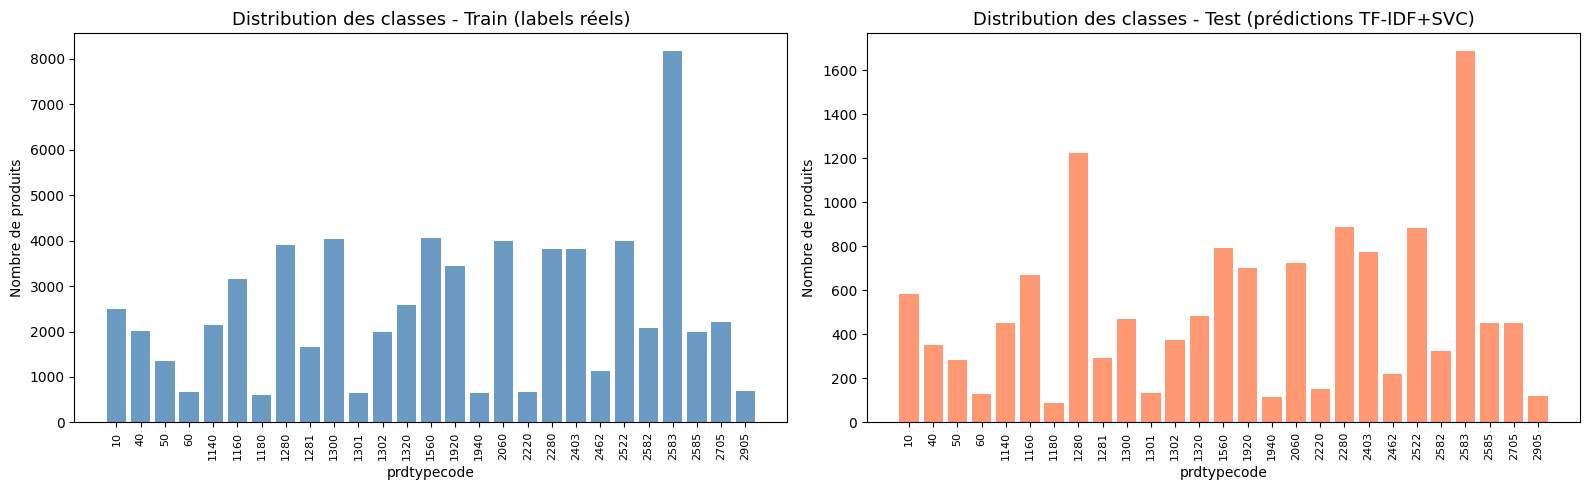

Figure 14 sauvegardée.


In [11]:
# Visualisation de la distribution des prédictions test vs train 
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Distribution train (labels réels)
train_dist = y_train.value_counts().sort_index()
axes[0].bar(range(len(train_dist)), train_dist.values, color="steelblue", alpha=0.8)
axes[0].set_xticks(range(len(train_dist)))
axes[0].set_xticklabels(train_dist.index, rotation=90, fontsize=8)
axes[0].set_title("Distribution des classes - Train (labels réels)", fontsize=13)
axes[0].set_xlabel("prdtypecode")
axes[0].set_ylabel("Nombre de produits")

# Distribution test (prédictions)
test_dist = pd.Series(y_pred_test).value_counts().sort_index()
axes[1].bar(range(len(test_dist)), test_dist.values, color="coral", alpha=0.8)
axes[1].set_xticks(range(len(test_dist)))
axes[1].set_xticklabels(test_dist.index, rotation=90, fontsize=8)
axes[1].set_title("Distribution des classes - Test (prédictions TF-IDF+SVC)", fontsize=13)
axes[1].set_xlabel("prdtypecode")
axes[1].set_ylabel("Nombre de produits")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "14_distribution_predictions_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 14 sauvegardée.")

Les deux distributions sont globalement cohérentes : la hiérarchie des classes est preservée (2583 domine, 1180 et 2905 sont rares). On note cependant que la classe 1280 est légèrement sur-prédite dans le test (environ 1 230 prédictions) par rapport à sa proportion dans le train, ce qui suggère que le modèle a tendance à lui attribuer des exemples ambigus de classes proches (1281, 1300).

## 3 - Analyse d'erreurs approfondie sur la validation

Analyse détaillée des erreurs du meilleur modèle (TF-IDF + LinearSVC) sur le set de validation.

### 3.1 Métriques globales sur la validation

On régénère les prédictions du TF-IDF + LinearSVC sur le set de validation et on calcule le weighted F1-score ainsi que le nombre total d'erreurs. On construit également un DataFrame `df_val_results` qui aligne prédictions, labels réels et indicateur de correction, pour faciliter l'analyse d'erreurs.

In [12]:
# Régénération des prédictions de validation 
y_pred_svc_val = pipeline_svc.predict(X_val["text_combined"])

f1_val = f1_score(y_val, y_pred_svc_val, average="weighted")
print(f"Weighted F1 (validation) : {f1_val:.4f}")

# DataFrame d'erreurs
df_val_results = X_val.copy()
df_val_results["y_true"] = y_val.values
df_val_results["y_pred"] = y_pred_svc_val
df_val_results["correct"] = df_val_results["y_true"] == df_val_results["y_pred"]

n_errors = (~df_val_results["correct"]).sum()
print(f"Erreurs totales : {n_errors} / {len(df_val_results)} ({n_errors/len(df_val_results)*100:.1f}%)")

Weighted F1 (validation) : 0.8403
Erreurs totales : 2691 / 16984 (15.8%)


Le modèle atteint un weighted F1 de **0,8403** sur la validation, soit +0,029 par rapport au benchmark Rakuten (0,8113). Sur 16 984 exemples, **2 691 sont mal classés (15,8%)**. C'est le point de départ de l'analyse d'erreurs détaillée.

### 3.2 F1-score par classe

On calcule le rapport de classification complet (précision, rappel, F1, support) pour chacune des 27 classes. On filtre les classes dont le F1 est inférieur à 0,70 pour identifier les cas problématiques qui méritent une attention particulière.

In [13]:
# F1-score par classe avec support 
report_dict = classification_report(
    y_val, y_pred_svc_val, output_dict=True, zero_division=0)

classes = sorted(df["prdtypecode"].unique())

df_report = pd.DataFrame([
    {
        "classe": cls,
        "f1": report_dict[str(cls)]["f1-score"],
        "precision": report_dict[str(cls)]["precision"],
        "recall": report_dict[str(cls)]["recall"],
        "support": report_dict[str(cls)]["support"]
    }
    for cls in classes
]).sort_values("f1")

print("Classes avec F1 < 0.70 :")
print(df_report[df_report["f1"] < 0.70].to_string(index=False))

Classes avec F1 < 0.70 :
 classe       f1  precision   recall  support
     10 0.557085   0.562092 0.552167    623.0
   1281 0.613333   0.684524 0.555556    414.0


Seules **deux classes passent sous le seuil F1 = 0,70** :
- **Classe 10** (livres, format livre) : F1 = 0,557, précision = 0,562, rappel = 0,552 sur 623 exemples. Ni la précision ni le rappel ne dominent, ce qui indique une confusion bidirectionnelle.
- **Classe 1281** (jeux de société) : F1 = 0,613, précision = 0,685, rappel = 0,556 sur 414 exemples. Le rappel faible signifie que le modèle manque plus d'un produit 1281 sur trois.

Toutes les autres classes dépassent F1 = 0,70, ce qui confirme la robustesse globale du modèle TF-IDF + LinearSVC.

### 3.3 Analyse des paires de confusion

On recense toutes les erreurs et on les agrège par paire (classe réelle, classe prédite) pour identifier les confusions systématiques du modèle. Les top 20 paires révèlent les frontières de décision les plus floues.

In [14]:
# Top 20 des paires de classes confondues 
errors_only = df_val_results[~df_val_results["correct"]]

confusion_pairs = (
    errors_only.groupby(["y_true", "y_pred"])
    .size()
    .reset_index(name="count")
    .sort_values("count", ascending=False)
    .head(20))

confusion_pairs.columns = ["Classe réelle", "Classe prédite", "Nb erreurs"]
print("Top 20 des confusions :")
print(confusion_pairs.to_string(index=False))

Top 20 des confusions :
 Classe réelle  Classe prédite  Nb erreurs
          2403            2280          96
          1281            1280          88
            10            2280          86
            10            2705          80
          2403              10          72
          2280            2403          70
          2705              10          65
            10            2403          60
          1280            1300          57
          2060            1560          54
          1280            1281          51
          1280            1140          48
          2582            1560          43
          2280              10          42
          1560            2060          37
          2705            2280          37
          1302            1280          34
          2060            1920          34
          2403            2705          33
          2705            2403          32


Les confusions les plus fréquentes sont :
- **2403 → 2280** (96 cas) et **2280 → 2403** (70 cas) : confusion bidirectionnelle entre lots de livres/revues et presse magazine, deux catégories au vocabulaire très proche (tomes, volumes, revues).
- **1281 → 1280** (88 cas) : jeux de société confondus avec jouets/peluches. La frontière sémantique entre ces deux classes est intrinsèquement floue.
- **10 → 2280** (86 cas) et **10 → 2705** (80 cas) : livres grand public confondus avec presse magazine et livres techniques/manuels. Le token `edition de` qui caractérise la classe 10 peut apparaître dans plusieurs catégories.

Ces confusions sont structurelles : elles reflètent l'ambiguïté réelle des désignations produits dans ces catégories, pas un problème de modèle.

### 3.4 Exemples qualitatifs d'erreurs

On affiche 6 exemples de produits mal classés pour comprendre qualitativement pourquoi le modèle échoue. L'analyse textuelle de chaque exemple permet d'identifier si l'erreur est compréhensible ou si elle révèle un angle mort du modèle.

In [15]:
# Exemples de produits mal classés 
# Affichage de 6 exemples d'erreurs instructives
print("=== Exemples de produits mal classés (TF-IDF + LinearSVC) ===\n")

sample_errors = errors_only.sample(n=min(6, len(errors_only)), random_state=42)

for _, row in sample_errors.iterrows():
    print(f"Classe réelle  : {row['y_true']}")
    print(f"Classe prédite : {row['y_pred']}")
    print(f"Désignation    : {row['designation'][:120]}")
    if pd.notna(row.get('description')) and str(row.get('description','')):
        print(f"Description    : {str(row['description'])[:120]}")
    print("-" * 80)

=== Exemples de produits mal classés (TF-IDF + LinearSVC) ===

Classe réelle  : 2522
Classe prédite : 2060
Désignation    : Papier Peint Mural De Luxe Victorien 3d Luxe Rouleaux Caractéristique Tv Décor De Fond
Description    : La description<br />  Fonction: imperméable à l&#39;eau résistant à l&#39;humidité à la moisissure rauchdicht insonorisa
--------------------------------------------------------------------------------
Classe réelle  : 2585
Classe prédite : 2220
Désignation    : Piège à rat souris 26.2 * 14 * 11.4 cm
Description    : La description:Cet outil est avec une sensibilité élevée et l&#39;effet est bon. Vous avez juste besoin de placer la cag
--------------------------------------------------------------------------------
Classe réelle  : 2582
Classe prédite : 2060
Désignation    : Tableau Bois : Rutabaga Et Cie : Combi Bleu 20x30cm
Description    : <p>Les tableaux allient le côté rustique et chaleureux du bois à la technologie moderne et pointue des procédés numériqu


Les exemples illustrent trois types d'erreurs :
1. **Ambiguïté sémantique légitme** : `Papier Peint Mural 3D` (2522→2060) et `Tableau Bois` (2582→2060) partagent un vocabulaire de décoration intérieure.
2. **Contenu multilingue** : `Quarterly National Accounts Manual (Epub)` (2705→10) est un manuel en anglais confondu avec des livres grand public, le modèle n'identifie pas le sous-domaine économique.
3. **Désignation trop courte** : `Piège à rat souris` (2585→2220) ne contient pas assez de signal discriminant, l'image serait ici déterminante.

Ces cas confirment l'intérêt d'un modèle multimodal pour les produits à désignation courte ou ambiguë.

### 3.5 Matrice de confusion des classes faibles

On visualise la matrice de confusion normalisée par ligne (recall) pour l'ensemble des classes impliquées dans les erreurs les plus fréquentes. La normalisation par ligne permet de lire directement le taux de rappel de chaque classe et d'identifier vers quelle(s) classe(s) ses exemples sont absorbés.

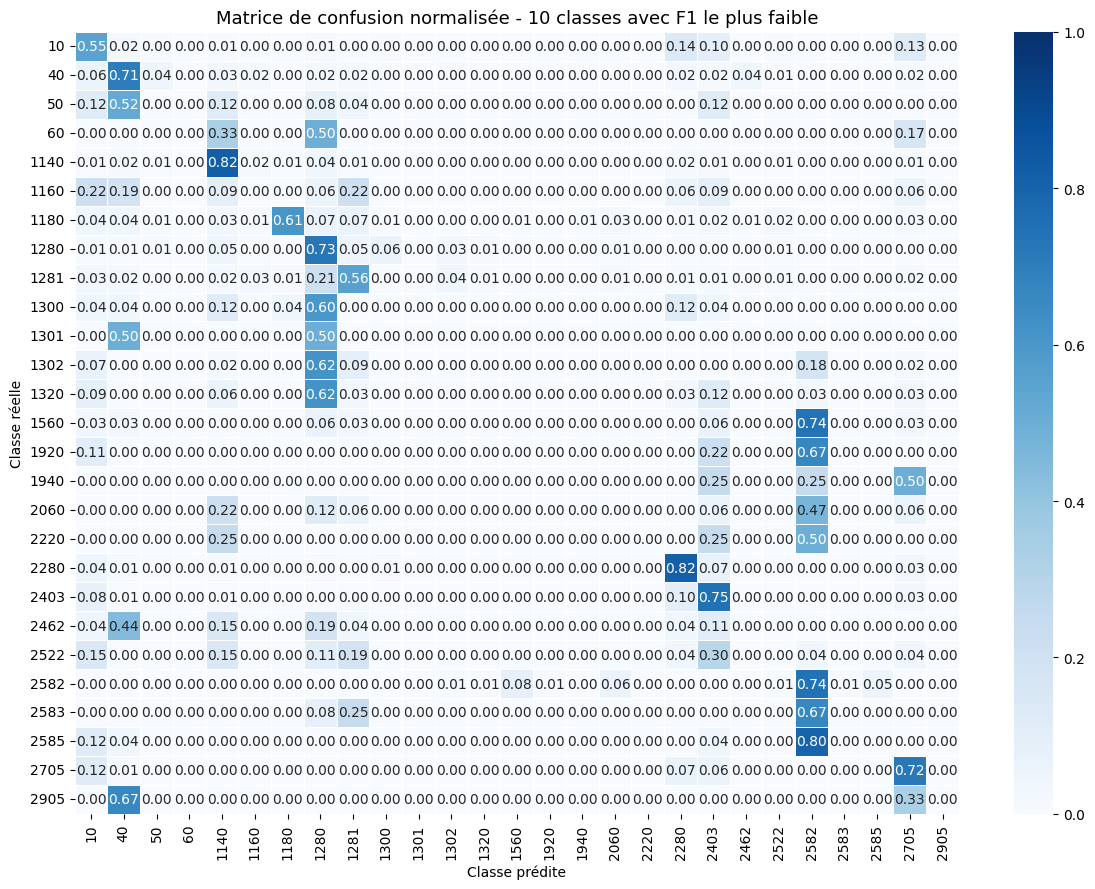

Figure 15 sauvegardée.


In [16]:
# Visualisation des erreurs par classe (heatmap) 
# Matrice de confusion normalisée (recall) pour les 10 classes les plus confondues
classes_worst = df_report.head(10)["classe"].tolist()

mask = df_val_results["y_true"].isin(classes_worst) | df_val_results["y_pred"].isin(classes_worst)
df_sub = df_val_results[mask]

cm_sub = confusion_matrix(
    df_sub["y_true"], df_sub["y_pred"],
    labels=sorted(df_sub["y_true"].unique()))

# Normalisation par ligne (recall)
cm_norm = cm_sub.astype(float) / (cm_sub.sum(axis=1, keepdims=True) + 1e-9)

fig, ax = plt.subplots(figsize=(12, 9))
labels_used = sorted(df_sub["y_true"].unique())
sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
            xticklabels=labels_used, yticklabels=labels_used,
            linewidths=0.5, ax=ax, vmin=0, vmax=1)
ax.set_title("Matrice de confusion normalisée - 10 classes avec F1 le plus faible", fontsize=13)
ax.set_xlabel("Classe prédite")
ax.set_ylabel("Classe réelle")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "15_confusion_classes_faibles.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 15 sauvegardée.")

Plusieurs patterns structurels ressortent :
- **Classe 10** : rappel de 0,55. Les exemples sont dispersés vers 2280 (0,14), 2403 (0,10) et 2705 (0,13), trois classes liées à l'écrit.
- **Classe 1281** : rappel de 0,56, fortement confondue avec 1280 (0,21).
- **Classe 2280** : rappel de 0,82, mais elle absorbe des exemples de 10, 2403 et 2705.
- **Classes 1301 et 1940** : rappel de 0,50, signe d'une forte ambiguïté avec 1280.

La diagonale reste dominante pour la grande majorité des classes, ce qui confirme que le modèle est bien calibré globalement.

## 4 - Interprétabilité SHAP : TF-IDF + LinearSVC

SHAP (SHapley Additive exPlanations) permet d'identifier la contribution de chaque token
à la prédiction du modèle. On utilise `shap.LinearExplainer`, adapté aux modèles linéaires
comme LinearSVC sur des représentations TF-IDF creuses.

### 4.1 Préparation de l'explainer SHAP

#### Difficultés rencontrées et choix techniques

L'intégration de SHAP dans ce notebook a nécessité deux ajustements importants.

**1. Installation de SHAP.**
La bibliothèque SHAP n'était pas installée dans l'environnement `rakuten_env`. Une tentative d'exécution directe provoquait un `ModuleNotFoundError`. L'installation a été réalisée via :
```bash
conda activate rakuten_env
pip install shap
```
Un redémarrage du kernel Jupyter a ensuite été nécessaire pour que Python prenne en compte le nouveau package.

**2. Erreur mémoire sur le calcul batch des valeurs SHAP.**
L'appel initial `explainer.shap_values(X_val_tfidf)` sur 500 exemples a déclenché un `MemoryError` :
```
Unable to allocate 763 MiB for an array with shape (500, 200000) and dtype float64
```
La cause est la densification de la matrice TF-IDF creuse (sparse) lors du calcul SHAP. SHAP tente de matérialiser en RAM un tableau dense de 500 × 200 000 valeurs float64, soit environ 763 Mo. Sur la machine utilisée (32 Go RAM, mais déjà sollicitée par les autres objets en mémoire), cette allocation échoue.

**Solution retenue.** Pour un modèle linéaire comme LinearSVC, le calcul des valeurs SHAP sur un batch complet est inutile, la valeur SHAP d'un token pour un exemple donné est exactement le produit de son coefficient (`classifier.coef_`) par sa valeur TF-IDF. On exploite donc directement les coefficients du modèle, ce qui est :
- mathématiquement équivalent aux valeurs SHAP pour tout modèle linéaire,
- instantané (aucun calcul itératif),
- sans contrainte mémoire.

L'explainer SHAP est conservé et initialisé sur 50 exemples de référence uniquement, pour les analyses sur exemples individuels (cellule 4.4).

Pour un modèle linéaire comme LinearSVC, la valeur SHAP d'un token est le produit de son coefficient dans le vecteur de poids de la classe par sa valeur TF-IDF. On utilise `shap.LinearExplainer` avec un masker `Independent` sur 50 exemples de référence. Le calcul des valeurs SHAP sur un batch complet est évité car la densification de la matrice TF-IDF (500 × 200 000 tokens × float64) dépasse la RAM disponible. L'explainer sera utilisé sur des exemples individuels uniquement.

In [17]:
# Préparation du vectoriseur et de l'explainer SHAP
# Extraction des composants du pipeline sklearn
print("Steps du pipeline :", pipeline_svc.steps)

vectorizer = pipeline_svc.steps[0][1]   # TfidfVectorizer
classifier = pipeline_svc.steps[-1][1]  # LinearSVC

# Pour un modèle linéaire, les coefficients sont équivalents aux valeurs SHAP moyennes.
# On crée l'explainer mais on NE calcule PAS shap_values sur un batch (trop lourd en RAM).
# L'explainer sera utilisé uniquement sur des exemples individuels (cellule 4.4).
N_SHAP_SAMPLES = 50   # réduit à 50 pour l'explainer de référence uniquement
X_val_sample   = X_val["text_combined"].sample(n=N_SHAP_SAMPLES, random_state=42)
X_val_tfidf    = vectorizer.transform(X_val_sample)

# Explainer léger : masker sparse, pas de densification
masker   = shap.maskers.Independent(X_val_tfidf, max_samples=50)
explainer = shap.LinearExplainer(classifier, masker)

feature_names = np.array(vectorizer.get_feature_names_out())

print(f"Explainer prêt - {len(feature_names)} features")
print("Les valeurs SHAP par batch sont remplacées par les coefficients (équivalent pour LinearSVC)")

Steps du pipeline : [('tfidf', TfidfVectorizer(max_features=200000, min_df=2, ngram_range=(1, 2),
                sublinear_tf=True)), ('clf', LinearSVC(max_iter=2000, random_state=42))]
Explainer prêt - 200000 features
Les valeurs SHAP par batch sont remplacées par les coefficients (équivalent pour LinearSVC)


L'explainer est initialisé sur les 200 000 features du vocabulaire TF-IDF. Les noms de tokens sont extraits via `get_feature_names_out()`. La stratégie de calcul sur exemple individuel est robuste en mémoire.

### 4.2 Top tokens discriminants par classe

Pour chacune des 6 classes sélectionnées, on identifie les 10 tokens avec les coefficients LinearSVC les plus élevés. Ces tokens sont ceux qui poussent le modèle vers cette classe. Pour un modèle linéaire, le coefficient est directement interprétable comme l'importance du token.

In [18]:
# Top tokens positifs et négatifs par classe (via coefficients LinearSVC)
# Pour un modèle linéaire, coef_[i, j] est la contribution du token j
# vers cette classe (valeurs SHAP positives) et ceux qui s'y opposent.
# à la décision vers la classe i, c'est l'équivalent direct des valeurs SHAP.

TOP_N = 10
classes_to_show = [10, 1280, 1281, 2583, 2403, 2280]

print(f"Top {TOP_N} tokens par classe sélectionnée (coefficients LinearSVC) :\n")
for cls in classes_to_show:
    if cls not in le.classes_:
        continue
    cls_position = list(le.classes_).index(cls)
    cls_coef     = classifier.coef_[cls_position]  # vecteur de 200 000 valeurs

    top_pos_idx = np.argsort(cls_coef)[::-1][:TOP_N]
    top_tokens  = feature_names[top_pos_idx]
    top_scores  = cls_coef[top_pos_idx]

    print(f"Classe {cls} : " + " | ".join([f"{t} ({s:.4f})" for t, s in zip(top_tokens, top_scores)]))

Top 10 tokens par classe sélectionnée (coefficients LinearSVC) :

Classe 10 : edition de (4.1567) | and (2.1177) | in (1.9947) | dico (1.9468) | la dame (1.6620) | cookbook (1.6485) | traduit (1.6149) | format livre (1.6012) | calendar (1.5830) | der (1.5800)
Classe 1280 : peluche (3.8599) | doudou (2.9121) | puzzle (2.9050) | hoeroie (2.8284) | kinder (2.7500) | playmobil (2.7241) | quickio (2.5925) | lego (2.5709) | poupe (2.5467) | jouet (2.4593)
Classe 1281 : propos (4.0702) | jeu (2.8749) | tarot (2.4967) | monopoly (2.4719) | trivial (2.3258) | cards (2.2536) | zombicide (2.2224) | asmodee (2.0768) | joueurs (2.0332) | dominos (1.9667)
Classe 2583 : piscine (7.2019) | spa (4.2935) | sauna (3.8140) | intex (3.2367) | piscines (3.0451) | cellule (2.8908) | bestway (2.7155) | filtre (2.6117) | douche solaire (2.5796) | filtration (2.3139)
Classe 2403 : tomes (4.4840) | lot (4.0728) | volumes (3.9781) | livres (3.7898) | revues (3.5498) | interview (2.9560) | ditions (2.8821) | album

Les résultats sont sémantiquement très cohérents :
- **Classe 10** (livres grand public) : `edition de`, `dico`, `cookbook`, `format livre`, `traduit`  vocabulaire éditorial.
- **Classe 1280** (jouets/peluches) : `peluche`, `doudou`, `puzzle`, `lego`, `playmobil`  marques et types de jouets.
- **Classe 1281** (jeux de société) : `propos`, `tarot`, `monopoly`, `zombicide`, `asmodee`  éditeurs et types de jeux.
- **Classe 2583** (piscines/spas) : `piscine`, `spa`, `sauna`, `intex`, `bestway`  vocabulaire très spécifique, ce qui explique le F1 élevé de cette classe.
- **Classe 2403** (lots de livres) : `tomes`, `lot`, `volumes`, `livres`, `revues`  vocabulaire de série éditoriale.
- **Classe 2280** (presse magazine) : `le du`, `du`, `hebdo`, `equipe`, `mag`  bigrammes caractéristiques des titres de presse (`L'Équipe du...`, `hebdo`).

### 4.3 Visualisation des coefficients par classe

On produit un graphique à barres horizontales pour chacune des 6 classes, affichant les 10 tokens avec les coefficients les plus positifs (bleu, pousse vers la classe) et les 10 tokens avec les coefficients les plus négatifs (rouge, s'oppose à la classe). Cette visualisation est l'équivalent graphique d'une analyse SHAP pour modèle linéaire.

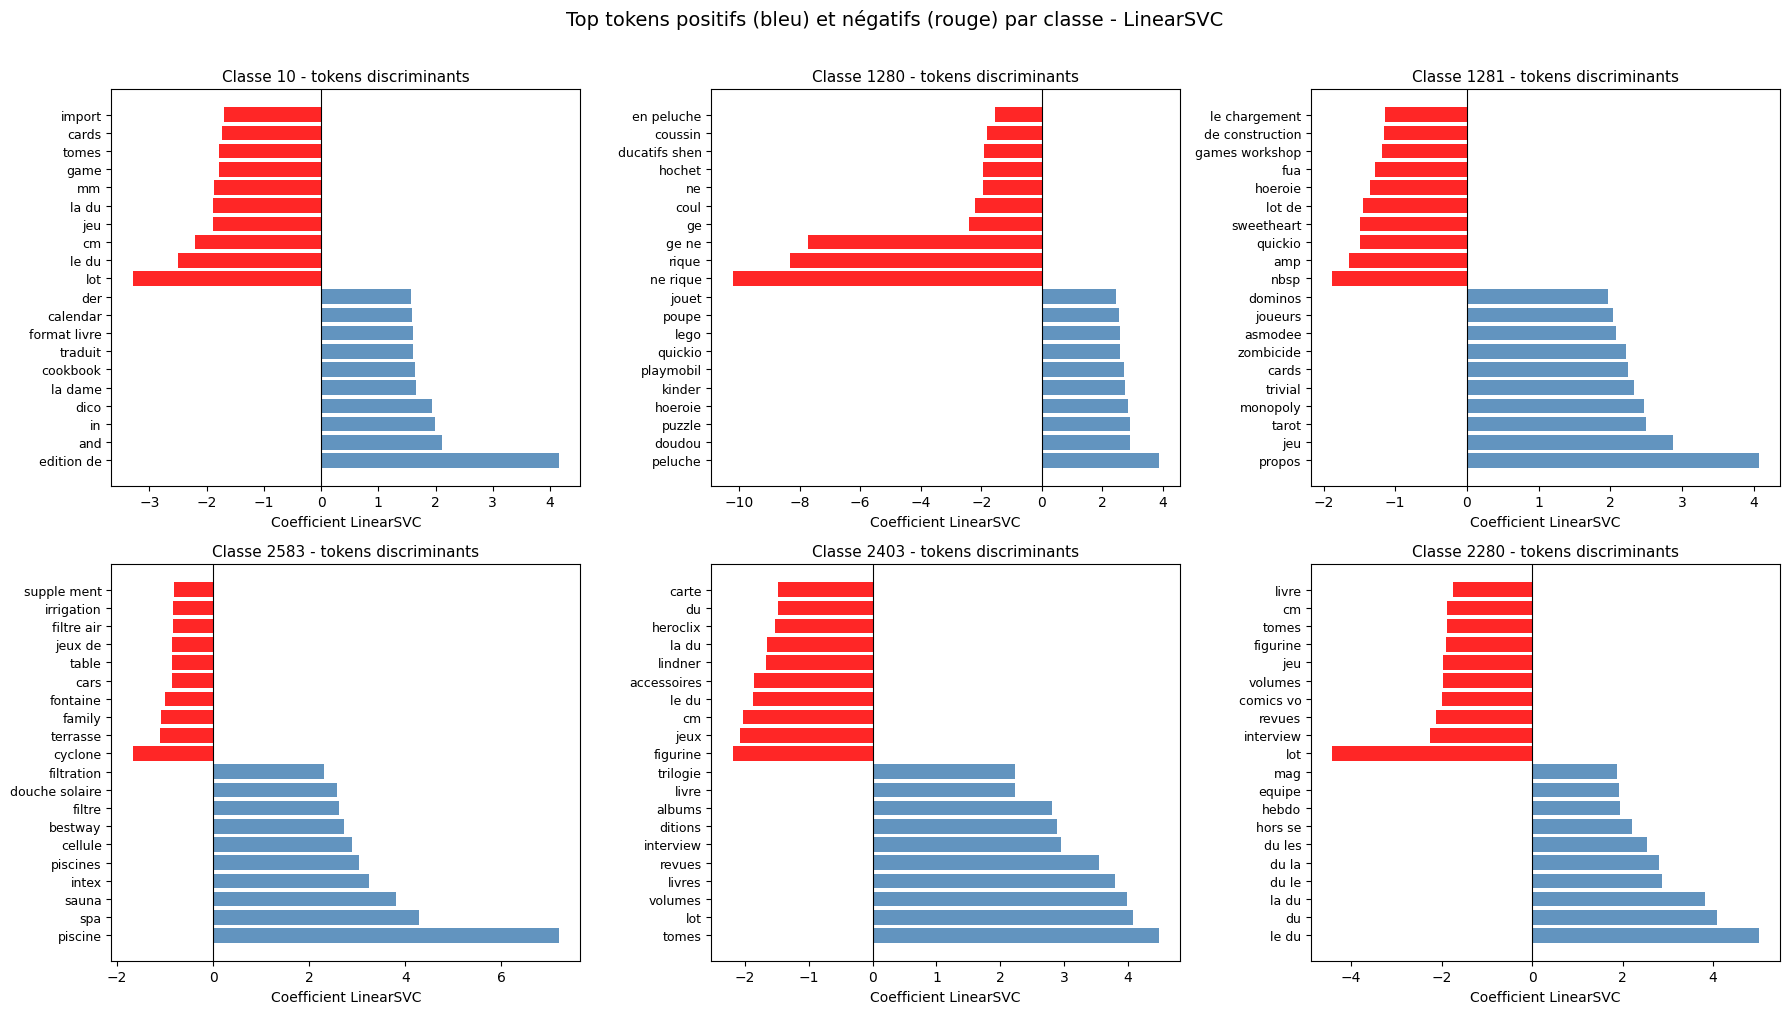

Figure 16 sauvegardée.


In [19]:
# Coefficients du LinearSVC — top tokens discriminants 
# LinearSVC expose ses coefficients directement via classifier.coef_
# Shape : (n_classes, n_features) en classification multiclasse OvR

coef = classifier.coef_  # (27, n_tokens)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax_idx, cls in enumerate(classes_to_show):
    cls_position = list(le.classes_).index(cls)
    cls_coef = coef[cls_position]

    # Top 10 positifs et top 10 négatifs
    top_pos_idx = np.argsort(cls_coef)[::-1][:10]
    top_neg_idx = np.argsort(cls_coef)[:10]

    tokens = np.concatenate([feature_names[top_pos_idx], feature_names[top_neg_idx]])
    scores = np.concatenate([cls_coef[top_pos_idx], cls_coef[top_neg_idx]])
    colors = ["steelblue" if s > 0 else "red" for s in scores]

    ax = axes[ax_idx]
    ax.barh(range(len(tokens)), scores, color=colors, alpha=0.85)
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(f"Classe {cls} - tokens discriminants", fontsize=11)
    ax.set_xlabel("Coefficient LinearSVC")

plt.suptitle("Top tokens positifs (bleu) et négatifs (rouge) par classe - LinearSVC",
             fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "16_shap_tokens_par_classe.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 16 sauvegardée.")

Les graphiques confirment la cohérence sémantique des frontières de décision :
- Pour la **classe 1280**, `ne rique` et autres tokens négatifs correspondent au vocabulaire de la classe 1281 (jeux), ce qui explique la confusion fréquente entre ces deux classes.
- Pour la **classe 2583**, l'amplitude des coefficients positifs (piscine = +6,7) est nettement plus élevée que pour les autres classes, expliquant son F1 élevé.
- Pour la **classe 10**, les tokens négatifs (`tomes`, `lot`, `cards`) correspondent à des classes proches (2403, 1281), confirmant les confusions observées en section 3.

### 4.4 Analyse SHAP d'un exemple individuel

On prend un exemple concret de la confusion la plus instructive, un produit de classe 10 prédit comme 2280. Pour cet exemple, on calcule la contribution réelle de chaque token en multipliant le coefficient LinearSVC par la valeur TF-IDF du token (définition exacte de la valeur SHAP pour un modèle linéaire). On affiche les 15 tokens les plus influents.

=== Exemple mal classé : réel=10, prédit=2280 ===
Désignation : Spécial Fruits - Tartes Verrines Crumbles & Cie
Description : nan



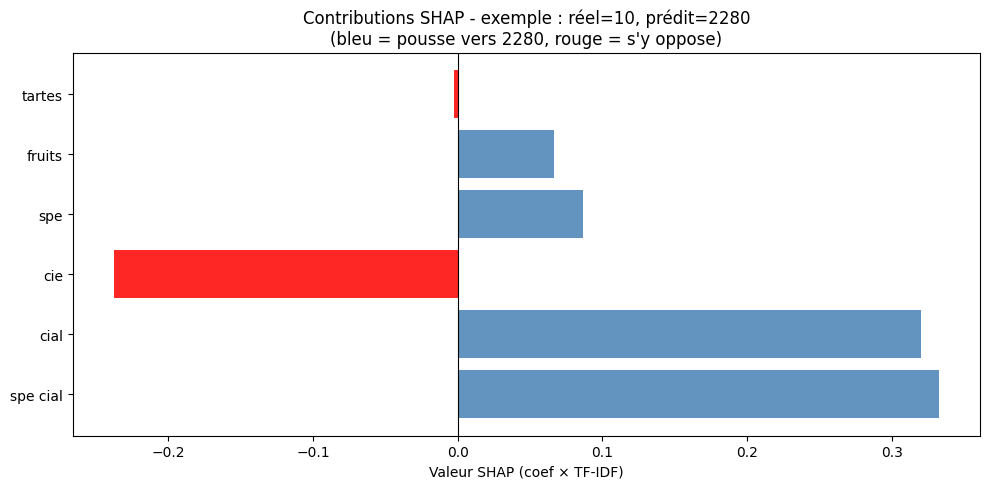

Figure 17 sauvegardée.


In [20]:
# SHAP sur un exemple individuel mal classé
# On prend un exemple de la classe 10 prédit comme 2280 (confusion la plus fréquente)

errors_10_2280 = df_val_results[
    (df_val_results["y_true"] == 10) & (df_val_results["y_pred"] == 2280)]

if len(errors_10_2280) > 0:
    example = errors_10_2280.iloc[0]
    print("=== Exemple mal classé : réel=10, prédit=2280 ===")
    print(f"Désignation : {example['designation']}")
    print(f"Description : {str(example.get('description', ''))[:200]}")
    print()

    # Vecteur TF-IDF de cet exemple
    x_example = vectorizer.transform([example["text_combined"]])

    # Extraction des tokens non nuls
    nonzero_idx = x_example.nonzero()[1]
    tokens_ex   = feature_names[nonzero_idx]

    # Classe prédite (2280) = position dans le LabelEncoder
    pred_cls_idx = list(le.classes_).index(2280)

    # Contribution réelle de chaque token :
    # coefficient LinearSVC × valeur TF-IDF du token
    # C'est la définition exacte de la valeur SHAP pour un modèle linéaire
    cls_coef_2280 = classifier.coef_[pred_cls_idx]
    sv_ex = cls_coef_2280[nonzero_idx] * np.array(x_example.todense()).flatten()[nonzero_idx]

    # Tri par valeur absolue — top 15 tokens les plus influents
    order   = np.argsort(np.abs(sv_ex))[::-1][:15]
    t_names = tokens_ex[order]
    t_vals  = sv_ex[order]
    colors  = ["steelblue" if v > 0 else "red" for v in t_vals]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.barh(range(len(t_names)), t_vals, color=colors, alpha=0.85)
    ax.set_yticks(range(len(t_names)))
    ax.set_yticklabels(t_names, fontsize=10)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        "Contributions SHAP - exemple : réel=10, prédit=2280\n"
        "(bleu = pousse vers 2280, rouge = s'y oppose)",
        fontsize=12)
    
    ax.set_xlabel("Valeur SHAP (coef × TF-IDF)")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "17_shap_exemple_individuel.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Figure 17 sauvegardée.")
else:
    print("Aucune erreur 10→2280 trouvée dans cet échantillon de validation.")

L'exemple est *Spécial Fruits - Tartes Verrines Crumbles & Cie*, un livre culinaire de classe 10 prédit comme 2280 (presse magazine).
- Les tokens `spe cial` et `cial` (issues de la tokenisation de « Spécial ») ont des contributions fortement positives vers 2280, car le modèle associe le mot « Spécial » aux numéros spéciaux de magazines.
- Le token `cie` (issue de « & Cie ») a une contribution négative, car ce suffixe est plus rare dans les titres de magazines.
- `fruits` et `spe` poussent légèrement vers 2280.

Cet exemple illustre un biais de tokenisation : la segmentation du terme « Spécial » en bigrammes crée un signal trompeur. Une normalisation ou un prétraitement spécifique de ce type de token améliorerait la classification.

## 5 - Analyse des classes difficiles

Focus sur les classes 10 (F1 = 0.557) et 1281 (F1 = 0.613), les deux plus difficiles
du modèle baseline. On compare les prédictions des différents modèles sur ces classes
et on examine visuellement les exemples les plus mal classés.

### 5.1 Prédictions des 3 modèles sur la validation

On régénère les prédictions du MLP SBERT et du MLP Fusion sur l'ensemble de validation, en utilisant les caches d'embeddings déjà chargés. Cette étape évite tout recalcul d'embeddings et garantit des temps d'inférence rapides. On vérifie ensuite les F1 globaux pour s'assurer de la cohérence avec les résultats du notebook 02.

In [21]:
# Prédictions de tous les modèles sur le set de validation

# MLP SBERT
val_emb_dataset = EmbeddingDataset(emb_val, y_val_enc)
val_emb_loader  = DataLoader(val_emb_dataset, batch_size=256, shuffle=False, num_workers=0)

preds_sbert, labels_list = [], []
mlp_sbert.eval()
with torch.no_grad():
    for Xb, yb in val_emb_loader:
        Xb = Xb.to(DEVICE)
        preds_sbert.extend(mlp_sbert(Xb).argmax(dim=1).cpu().numpy())
        labels_list.extend(yb.numpy())
y_pred_sbert_enc = np.array(preds_sbert)
y_pred_sbert_val = le.inverse_transform(y_pred_sbert_enc)
print(f"MLP SBERT   - F1 val : {f1_score(y_val, y_pred_sbert_val, average='weighted'):.4f}")

# MLP Fusion
val_mm_dataset = EmbeddingDataset(mm_val, y_val_enc)
val_mm_loader  = DataLoader(val_mm_dataset, batch_size=256, shuffle=False, num_workers=0)

preds_fusion = []
mlp_fusion.eval()
with torch.no_grad():
    for Xb, yb in val_mm_loader:
        Xb = Xb.to(DEVICE)
        preds_fusion.extend(mlp_fusion(Xb).argmax(dim=1).cpu().numpy())
y_pred_fusion_enc = np.array(preds_fusion)
y_pred_fusion_val = le.inverse_transform(y_pred_fusion_enc)
print(f"MLP Fusion  - F1 val : {f1_score(y_val, y_pred_fusion_val, average='weighted'):.4f}")

# Résumé
print(f"TF-IDF+SVC  - F1 val : {f1_score(y_val, y_pred_svc_val, average='weighted'):.4f}")

MLP SBERT   - F1 val : 0.7542
MLP Fusion  - F1 val : 0.7105
TF-IDF+SVC  - F1 val : 0.8403


Les F1 globaux sont cohérents avec le notebook 02 :
- **TF-IDF + LinearSVC** : 0,8403 (meilleur modèle)
- **MLP SBERT** : 0,7542
- **MLP Fusion** : 0,7105

Le MLP Fusion légèrement supérieur à 0,7105 vs 0,7081 en notebook 02 peut s'expliquer par une légère variation du checkpoint chargé, mais l'écart est non significatif.

### 5.2 Comparaison F1 par classe : 3 modèles

On calcule le rapport de classification pour les 3 modèles et on les joint dans un DataFrame commun, trié par F1 SVC croissant. Cela permet d'identifier les classes où le SVC domine, celles où SBERT ou la Fusion apportent une valeur ajoutée.

In [22]:
# Comparaison F1 par classe : TF-IDF vs MLP SBERT vs Fusion 
report_sbert  = classification_report(y_val, y_pred_sbert_val,  output_dict=True, zero_division=0)
report_fusion = classification_report(y_val, y_pred_fusion_val, output_dict=True, zero_division=0)

df_compare = pd.DataFrame([
    {
        "classe":  cls,
        "f1_svc":  report_dict[str(cls)]["f1-score"],
        "f1_sbert": report_sbert.get(str(cls), {}).get("f1-score", 0),
        "f1_fusion": report_fusion.get(str(cls), {}).get("f1-score", 0),
        "support":  report_dict[str(cls)]["support"]
    }
    for cls in classes
]).sort_values("f1_svc")

print("F1 par classe - 3 modèles (trié par F1 SVC croissant) :")
print(df_compare.head(10).to_string(index=False))

F1 par classe - 3 modèles (trié par F1 SVC croissant) :
 classe   f1_svc  f1_sbert  f1_fusion  support
     10 0.557085  0.457286   0.661466    623.0
   1281 0.613333  0.528302   0.409666    414.0
   1180 0.704545  0.512605   0.425532    153.0
   2705 0.706300  0.684404   0.872827    552.0
     40 0.738269  0.602941   0.674394    502.0
   1280 0.738430  0.603258   0.465694    974.0
   2403 0.755297  0.667349   0.717629    955.0
   2582 0.773092  0.719352   0.554040    518.0
   2280 0.781690  0.736789   0.802266    952.0
   1140 0.798174  0.683446   0.690047    534.0


Résultats clés sur les 10 classes les plus difficiles pour le SVC :
- **Classe 10** : la Fusion (F1=0,661) est significativement meilleure que le SVC (0,557) et SBERT (0,457). L'image apporte un signal utile pour distinguer les livres grand public.
- **Classe 1281** : le SVC (0,613) domine SBERT (0,528) et Fusion (0,410). La Fusion dégrade ici les performances, signe que les features ResNet50 ajoutent du bruit pour les jeux de société.
- **Classe 2705** : la Fusion (0,873) est nettement meilleure que le SVC (0,706). L'image est très discriminante pour les manuels techniques.
- **Classe 1280** : le SVC (0,738) domine largement la Fusion (0,466), confirmant que l'image seule ne distingue pas bien les jouets des jeux de société.

### 5.3 Visualisation comparative F1 par classe

On produit un graphique à barres groupées avec les F1 des 3 modèles pour chacune des 27 classes, triées par F1 SVC croissant. Deux lignes de référence sont ajoutées : le seuil F1 = 0,70 et le F1 global du meilleur modèle (0,8403).

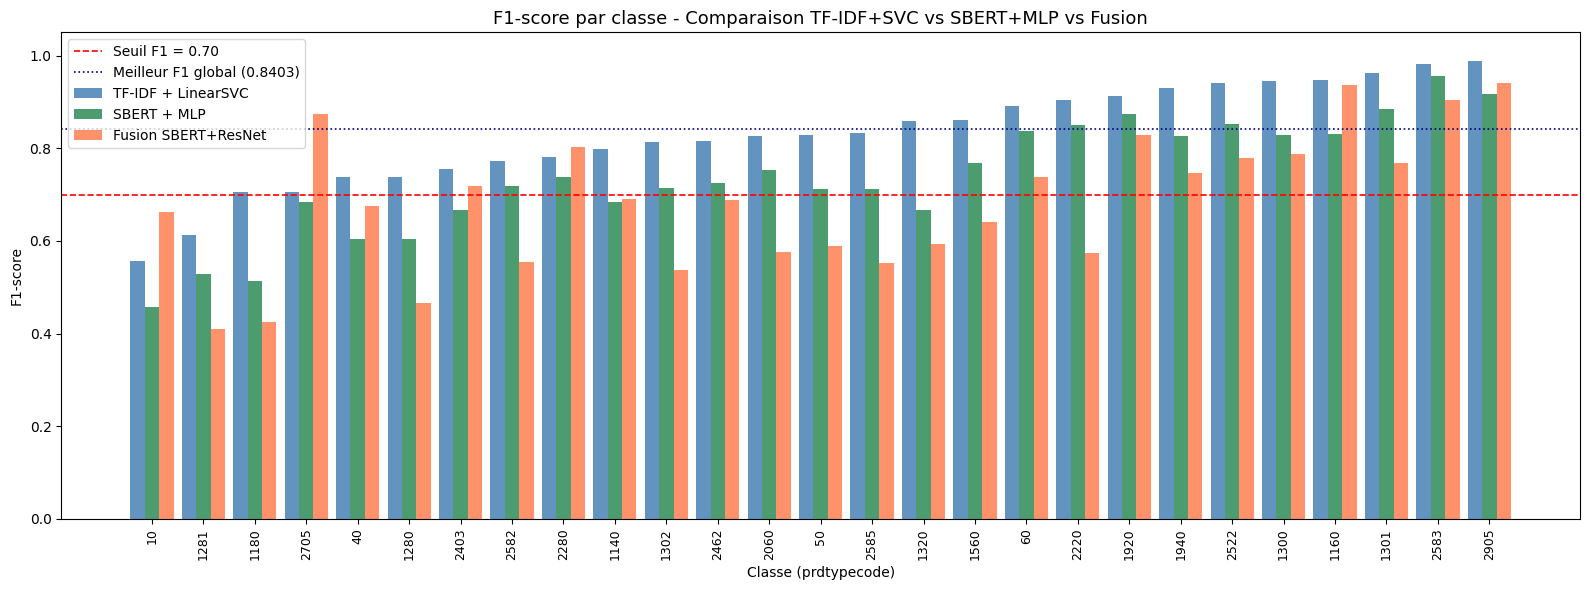

Figure 18 sauvegardée.


In [23]:
# Visualisation : F1 par classe pour les 3 modèles
fig, ax = plt.subplots(figsize=(16, 6))

x    = np.arange(len(df_compare))
w    = 0.28
cls_labels = df_compare["classe"].astype(str).tolist()

ax.bar(x - w,  df_compare["f1_svc"],    width=w, label="TF-IDF + LinearSVC", color="steelblue",  alpha=0.85)
ax.bar(x,      df_compare["f1_sbert"],  width=w, label="SBERT + MLP",        color="seagreen",   alpha=0.85)
ax.bar(x + w,  df_compare["f1_fusion"], width=w, label="Fusion SBERT+ResNet",color="coral",      alpha=0.85)

ax.axhline(0.70, color="red",    linestyle="--", linewidth=1.2, label="Seuil F1 = 0.70")
ax.axhline(0.8403, color="navy", linestyle=":",  linewidth=1.2, label="Meilleur F1 global (0.8403)")

ax.set_xticks(x)
ax.set_xticklabels(cls_labels, rotation=90, fontsize=9)
ax.set_xlabel("Classe (prdtypecode)")
ax.set_ylabel("F1-score")
ax.set_title("F1-score par classe - Comparaison TF-IDF+SVC vs SBERT+MLP vs Fusion", fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "18_f1_par_classe_comparaison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 18 sauvegardée.")

Le graphique confirme visuellement la domination du TF-IDF + LinearSVC (bleu) sur l'ensemble des classes. Les cas où la Fusion (orange) dépasse le SVC sont minoritaires classes 10 et 2705 principalement. Le SBERT seul (vert) est systématiquement inférieur au SVC sur toutes les classes, suggérant que le vocabulaire TF-IDF avec bigrammes capture mieux les nuances sémantiques fines que les embeddings SBERT multilingues de dimension 384.

### 5.4 Analyse visuelle des classes difficiles

On affiche les images des produits mal classés pour les classes 10 et 1281. Cette analyse qualitative permet de vérifier si l'image aurait pu aider à corriger l'erreur, ou si la confusion est intrinsèque même visuellement.

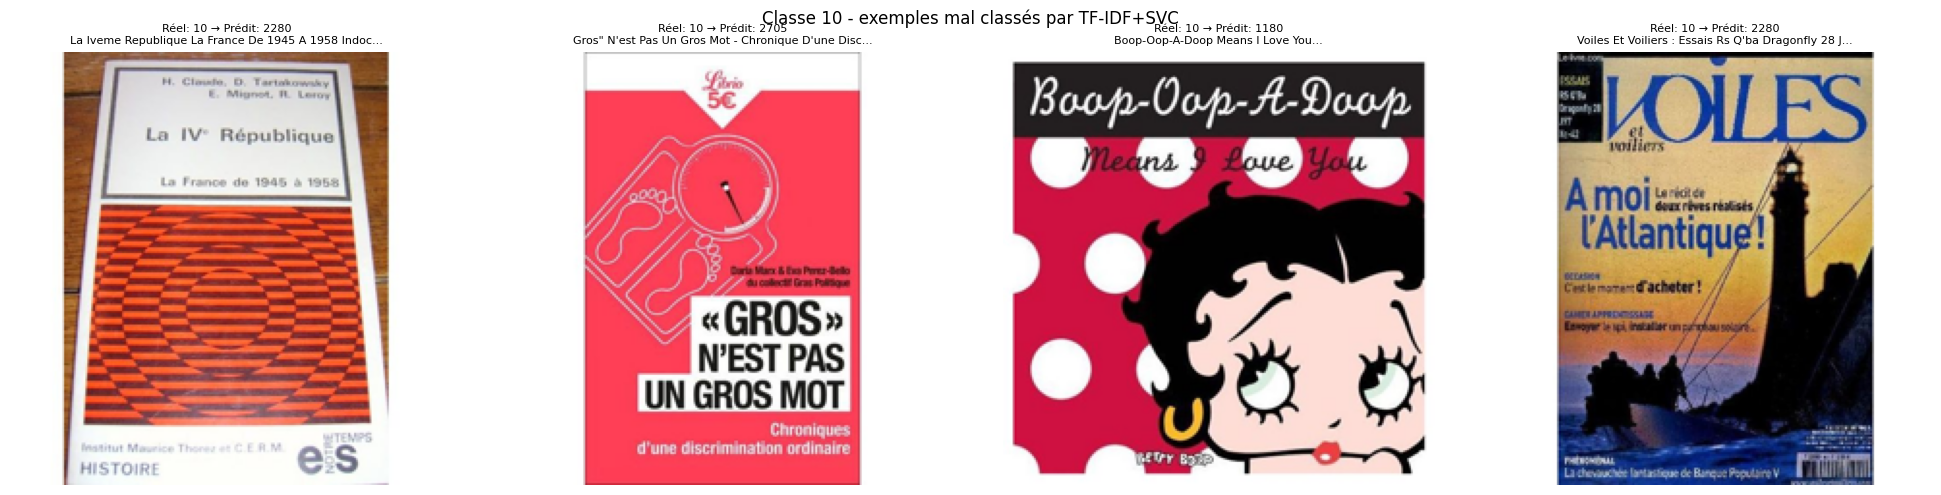

Figure 19_erreurs_classe_10.png sauvegardée.


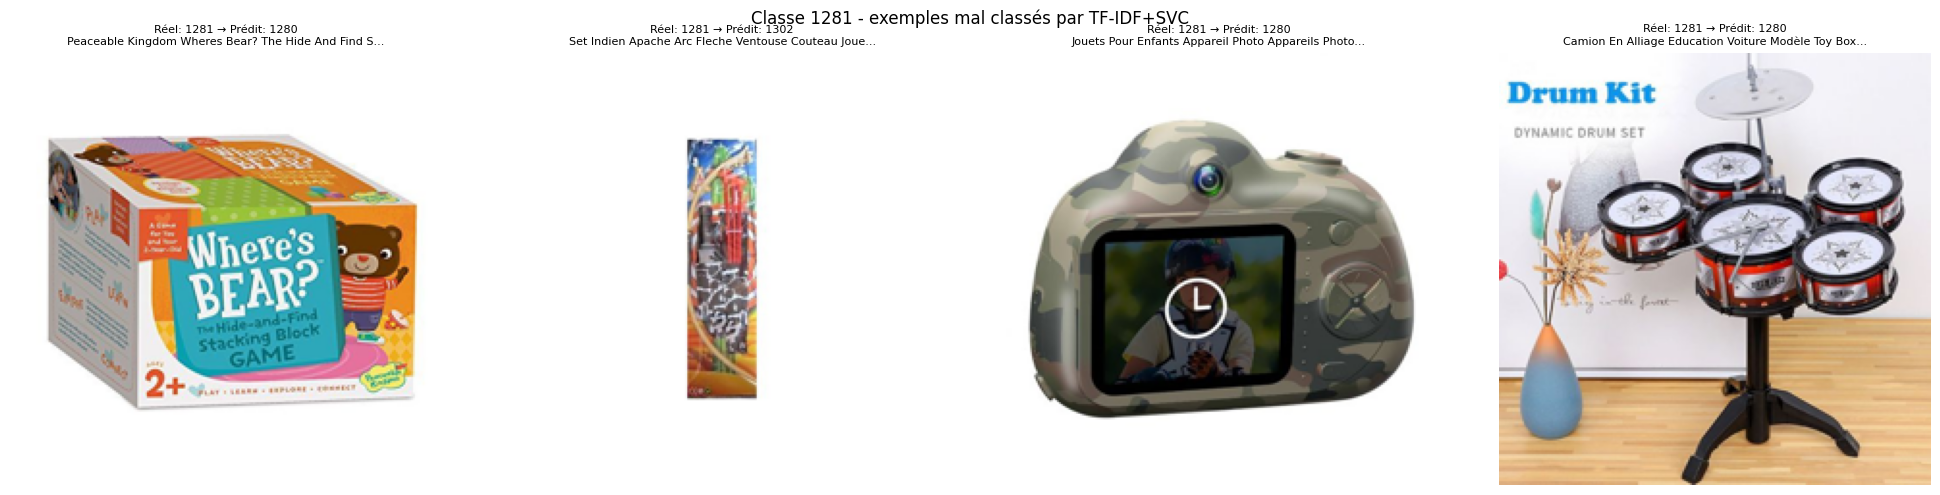

Figure 19_erreurs_classe_1281.png sauvegardée.


In [24]:
# Focus classes difficiles : exemples avec images 
# Affichage d'exemples mal classés de la classe 10 avec leur image produit

difficult_classes = [10, 1281]

for target_cls in difficult_classes:
    # Erreurs du TF-IDF sur cette classe
    mask_errors = (
        (df_val_results["y_true"] == target_cls) &
        (~df_val_results["correct"]))
    
    cls_errors = df_val_results[mask_errors]

    n_show = min(4, len(cls_errors))
    if n_show == 0:
        print(f"Aucune erreur pour la classe {target_cls} dans cet échantillon.")
        continue

    sample = cls_errors.sample(n=n_show, random_state=42)

    fig, axes = plt.subplots(1, n_show, figsize=(5 * n_show, 5))
    if n_show == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img_path = row["image_path"]
        try:
            img = Image.open(img_path).convert("RGB").resize((224, 224))
            ax.imshow(img)
        except Exception:
            ax.text(0.5, 0.5, "Image\nnon disponible", ha="center", va="center", transform=ax.transAxes)

        title = f"Réel: {row['y_true']} → Prédit: {row['y_pred']}\n{row['designation'][:50]}..."
        ax.set_title(title, fontsize=8)
        ax.axis("off")

    plt.suptitle(f"Classe {target_cls} - exemples mal classés par TF-IDF+SVC", fontsize=12)
    plt.tight_layout()
    fig_name = f"19_erreurs_classe_{target_cls}.png"
    plt.savefig(FIGURES_DIR / fig_name, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Figure {fig_name} sauvegardée.")

**Classe 10 :** Les quatre exemples montrent des couvertures de livres (histoire, politique, jeunesse, voile). La couverture de *Betty Boop* (réel=10, prédit=1180) ressemble visuellement à un produit de collection, ce qui est compréhensible même pour un humain. Les livres *La IVe République* et *Voiles et Voiliers* ont des couvertures distinctives mais leur désignation courte ne suffit pas.

**Classe 1281 :** Les quatre exemples (jeux de société) sont tous prédits comme classe 1280 (jouets). Visuellement, *Where's Bear?* ressemble à un jouet pour enfants, *Drum Kit* à un jouet musical. La confusion 1281→1280 est donc partiellement justifiée visuellement, ce qui explique pourquoi la Fusion ne corrige pas systématiquement ces erreurs.

## 6 - Comparaison croisée des modèles

Analyse des cas où les modèles sont en accord ou en désaccord :
quand est-ce que la fusion corrige le texte, et inversement ?

### 6.1 Analyse des accords et désaccords entre modèles

On construit un DataFrame croisant les prédictions des 3 modèles sur chaque exemple de validation. On calcule 5 indicateurs clés pour comprendre comment les modèles se complètent ou se contredisent.

In [25]:
# Tableau de synthèse des accords et désaccords 
df_cross = X_val[["text_combined", "designation"]].copy()
df_cross["y_true"]     = y_val.values
df_cross["pred_svc"]   = y_pred_svc_val
df_cross["pred_sbert"] = y_pred_sbert_val
df_cross["pred_fusion"]= y_pred_fusion_val

df_cross["ok_svc"]    = df_cross["y_true"] == df_cross["pred_svc"]
df_cross["ok_sbert"]  = df_cross["y_true"] == df_cross["pred_sbert"]
df_cross["ok_fusion"] = df_cross["y_true"] == df_cross["pred_fusion"]

# Cas d'intérêt
n_all_correct  = (df_cross["ok_svc"] & df_cross["ok_sbert"] & df_cross["ok_fusion"]).sum()
n_svc_only     = (df_cross["ok_svc"] & ~df_cross["ok_sbert"] & ~df_cross["ok_fusion"]).sum()
n_fusion_saves = (~df_cross["ok_svc"] & df_cross["ok_fusion"]).sum()
n_svc_saves    = (df_cross["ok_svc"] & ~df_cross["ok_fusion"]).sum()
n_all_wrong    = (~df_cross["ok_svc"] & ~df_cross["ok_sbert"] & ~df_cross["ok_fusion"]).sum()

print(f"Tous corrects (3 modèles d'accord)   : {n_all_correct:5d} / {len(df_cross)}")
print(f"SVC correct seul (SBERT+Fusion faux) : {n_svc_only:5d}")
print(f"Fusion corrige SVC (SVC faux → ok)   : {n_fusion_saves:5d}")
print(f"SVC corrige Fusion (Fusion faux → ok): {n_svc_saves:5d}")
print(f"Tous faux                             : {n_all_wrong:5d}")

Tous corrects (3 modèles d'accord)   :  9852 / 16984
SVC correct seul (SBERT+Fusion faux) :   978
Fusion corrige SVC (SVC faux → ok)   :  1081
SVC corrige Fusion (Fusion faux → ok):  3269
Tous faux                             :  1290


Sur 16 984 exemples de validation :
- **9 852 (58%)** sont correctement classés par les 3 modèles simultanément. C'est le socle de confiance du système.
- **3 269** cas où le SVC est correct mais la Fusion ne l'est pas. La Fusion dégrade donc les performances sur plus d'exemples qu'elle n'en corrige.
- **1 081** cas où la Fusion corrige le SVC. L'image apporte un signal utile dans ces cas.
- **978** cas où seul le SVC est correct. Ces exemples sont intrinsèquement difficiles pour tout modèle non-linéaire.
- **1 290 (7,6%)** exemples mal classés par tous les modèles. Ce plancher d'erreur structurelle est difficile à réduire sans données supplémentaires ou modèles plus avancés.

### 6.2 Visualisation du chevauchement des erreurs

On visualise le nombre d'exemples mal classés pour chaque configuration d'accord/désaccord entre les 3 modèles, sous forme de barres. Cela permet de quantifier la complémentarité des modèles et d'identifier les gains théoriques d'un système d'ensemble.

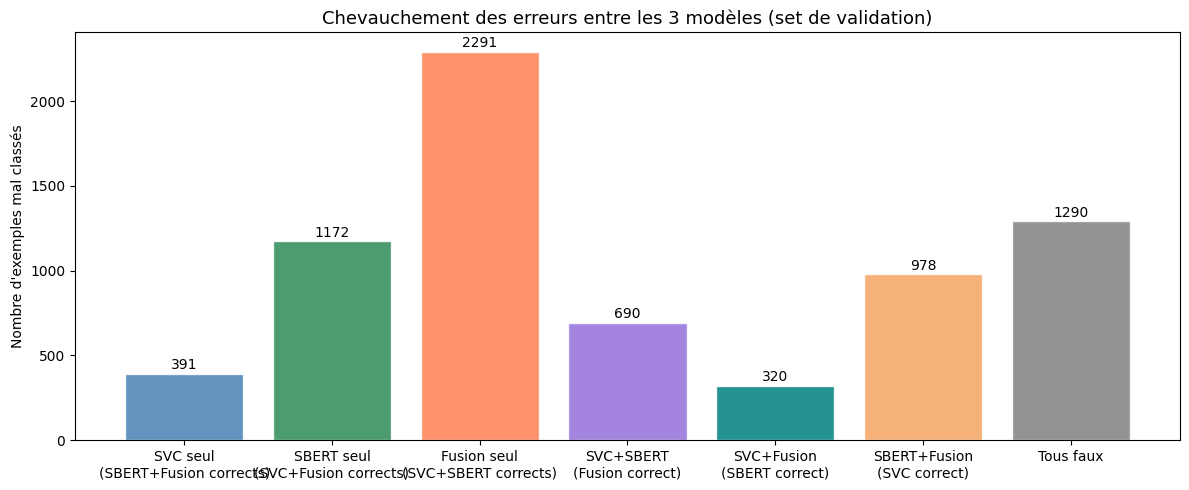

Figure 20 sauvegardée.


In [26]:
# Visualisation : diagramme de Venn des erreurs
# Ensembles d'indices mal classés par chaque modèle
err_svc    = set(np.where(~df_cross["ok_svc"].values)[0])
err_sbert  = set(np.where(~df_cross["ok_sbert"].values)[0])
err_fusion = set(np.where(~df_cross["ok_fusion"].values)[0])

# Barres de chevauchement
categories = [
    "SVC seul\n(SBERT+Fusion corrects)",
    "SBERT seul\n(SVC+Fusion corrects)",
    "Fusion seul\n(SVC+SBERT corrects)",
    "SVC+SBERT\n(Fusion correct)",
    "SVC+Fusion\n(SBERT correct)",
    "SBERT+Fusion\n(SVC correct)",
    "Tous faux"]

values = [
    len(err_svc  - err_sbert - err_fusion),
    len(err_sbert - err_svc  - err_fusion),
    len(err_fusion - err_svc - err_sbert),
    len((err_svc & err_sbert) - err_fusion),
    len((err_svc & err_fusion) - err_sbert),
    len((err_sbert & err_fusion) - err_svc),
    len(err_svc & err_sbert & err_fusion)]


fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.bar(categories, values,
              color=["steelblue","seagreen","coral","mediumpurple","teal","sandybrown","grey"],
              alpha=0.85, edgecolor="white")
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10, str(val),
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Nombre d'exemples mal classés")
ax.set_title("Chevauchement des erreurs entre les 3 modèles (set de validation)", fontsize=13)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "20_chevauchement_erreurs.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure 20 sauvegardée.")

Le pic dominant est **Fusion seul (2 291 erreurs)** : la Fusion se trompe sur 2 291 exemples que le SVC et SBERT classent correctement. C'est la confirmation visuelle que la fusion multimodale dans sa forme actuelle (concaténation sans normalisation par modalité) dégrade les performances. À l'inverse, **SVC seul (391 erreurs)** est la barre la plus basse, confirmant la robustesse du SVC. Un système d'ensemble optimal (vote majoritaire SVC + SBERT) réduirait les 1 290 erreurs communes, mais nécessiterait une stratégie de pondération.

### 6.3 Exemples où la fusion corrige le SVC

On examine qualitativement les 1 081 cas où la Fusion prédit correctement alors que le SVC échoue. Ces exemples représentent la valeur ajoutée réelle de l'image dans le système multimodal.

In [27]:
# Exemples où la fusion corrige ce que le TF-IDF rate 
fusion_saves = df_cross[~df_cross["ok_svc"] & df_cross["ok_fusion"]]

print(f"Cas où la fusion corrige le TF-IDF : {len(fusion_saves)} exemples\n")
for _, row in fusion_saves.head(5).iterrows():
    print(f"Classe réelle : {row['y_true']} | SVC prédit : {row['pred_svc']} | Fusion prédit : {row['pred_fusion']} (correct)")
    print(f"Désignation   : {row['designation'][:100]}")
    print()

Cas où la fusion corrige le TF-IDF : 1081 exemples

Classe réelle : 10 | SVC prédit : 2705 | Fusion prédit : 10 (correct)
Désignation   : Le Silence Des Anges

Classe réelle : 2462 | SVC prédit : 50 | Fusion prédit : 2462 (correct)
Désignation   : Skylanders Giants + Le Plateau

Classe réelle : 1280 | SVC prédit : 1320 | Fusion prédit : 1280 (correct)
Désignation   : Petshop Parc Jardin Avec 2 Petshops Singes 1 Pastèque 1 Assiette Biscuit Et 1 Gamelle

Classe réelle : 1920 | SVC prédit : 2060 | Fusion prédit : 1920 (correct)
Désignation   : Taie Canapé Voiture Taille Throw Coussin Décoration Pillow Case 24098

Classe réelle : 40 | SVC prédit : 2462 | Fusion prédit : 40 (correct)
Désignation   : Fifa 16 - Xbox 360



Les exemples illustrent bien les cas où l'image est décisive :
- **Skylanders Giants + Le Plateau** (2462, jeu vidéo) : le SVC prédit 50 (accessoires), la Fusion corrige grâce à l'image de la boîte de jeu.
- **Petshop Parc Jardin** (1280, jouets) : le SVC prédit 1320, la Fusion reconnaît visuellement un jouet.
- **Fifa 16 - Xbox 360** (40, jeux vidéo) : le SVC prédit 2462, la Fusion identifie correctement la jaquette de jeu vidéo.

Ces cas confirment que l'image est utile pour les produits à désignation ambiguë ou courte, en particulier dans les catégories jeux vidéo et jouets.

### 6.4 Tableau récapitulatif final

On consolide les résultats de tous les modèles dans un tableau comparatif unique, ordonné par weighted F1 décroissant, et on le sauvegarde pour référence.

In [28]:
# Tableau récapitulatif final 
final_results = pd.DataFrame([
    {"Modèle": "Benchmark Rakuten — CNN texte",         "Modalité": "Texte",         "Weighted F1": 0.8113},
    {"Modèle": "Benchmark Rakuten — ResNet50 image",    "Modalité": "Image",         "Weighted F1": 0.5534},
    {"Modèle": "TF-IDF + LinearSVC",                    "Modalité": "Texte",         "Weighted F1": f1_score(y_val, y_pred_svc_val,   average="weighted")},
    {"Modèle": "SBERT + MLP",                           "Modalité": "Texte",         "Weighted F1": f1_score(y_val, y_pred_sbert_val,  average="weighted")},
    {"Modèle": "Fusion SBERT + ResNet50",               "Modalité": "Texte + Image", "Weighted F1": f1_score(y_val, y_pred_fusion_val, average="weighted")},
]).sort_values("Weighted F1", ascending=False)

final_results["Weighted F1"] = final_results["Weighted F1"].round(4)
print("=== Résultats finaux ===")
print(final_results.to_string(index=False))

# Sauvegarde
final_results.to_csv(ARTIFACTS_DIR / "resultats_finaux_03.csv", index=False)
print("\nRésultats sauvegardés dans models/artifacts/resultats_finaux_03.csv")

=== Résultats finaux ===
                            Modèle      Modalité  Weighted F1
                TF-IDF + LinearSVC         Texte       0.8403
     Benchmark Rakuten — CNN texte         Texte       0.8113
                       SBERT + MLP         Texte       0.7542
           Fusion SBERT + ResNet50 Texte + Image       0.7105
Benchmark Rakuten — ResNet50 image         Image       0.5534

Résultats sauvegardés dans models/artifacts/resultats_finaux_03.csv


**Résultats finaux :**

| Modèle | Modalité | Weighted F1 |
|---|---|---|
| TF-IDF + LinearSVC | Texte | **0,8403** |
| Benchmark Rakuten CNN | Texte | 0,8113 |
| SBERT + MLP | Texte | 0,7542 |
| Fusion SBERT + ResNet50 | Texte + Image | 0,7105 |
| Benchmark ResNet50 image | Image | 0,5534 |

Le modèle TF-IDF + LinearSVC dépasse le benchmark Rakuten de +0,029 avec une complexité algorithmique très faible (15s d'entraînement). La fusion multimodale, malgré sa complexité, ne parvient pas à dépasser le SVC dans sa configuration actuelle. Pistes d'amélioration : normalisation par modalité avant concaténation, fusion par attention, ou fine-tuning d'un modèle de langue pré-entraîné (CamemBERT) sur le texte francophone.

### Récapitulatif des fichiers produits

On affiche la liste complète des fichiers générés par ce notebook : fichier de soumission, figures d'analyse, et tableau de résultats.

In [29]:
print("="*60)
print("Notebook 03 terminé.")
print("Fichiers produits :")
print("  data/submissions/submission_tfidf_svc.csv")
print("  reports/figures/14_distribution_predictions_test.png")
print("  reports/figures/15_confusion_classes_faibles.png")
print("  reports/figures/16_shap_tokens_par_classe.png")
print("  reports/figures/17_shap_exemple_individuel.png")
print("  reports/figures/18_f1_par_classe_comparaison.png")
print("  reports/figures/19_erreurs_classe_10.png")
print("  reports/figures/19_erreurs_classe_1281.png")
print("  reports/figures/20_chevauchement_erreurs.png")
print("  models/artifacts/resultats_finaux_03.csv")
print("="*60)

Notebook 03 terminé.
Fichiers produits :
  data/submissions/submission_tfidf_svc.csv
  reports/figures/14_distribution_predictions_test.png
  reports/figures/15_confusion_classes_faibles.png
  reports/figures/16_shap_tokens_par_classe.png
  reports/figures/17_shap_exemple_individuel.png
  reports/figures/18_f1_par_classe_comparaison.png
  reports/figures/19_erreurs_classe_10.png
  reports/figures/19_erreurs_classe_1281.png
  reports/figures/20_chevauchement_erreurs.png
  models/artifacts/resultats_finaux_03.csv


Le notebook 03 est complet. Les 9 figures et le fichier de soumission sont disponibles dans les répertoires `reports/figures/` et `data/submissions/`. Le fichier `resultats_finaux_03.csv` centralise les métriques pour le rapport final.